In [92]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np
import sr_fun
importlib.reload(sr_fun)
import pandas as pd
import re

# IOB Fits


Reading from configuration file: conf/iob_6.ini

Comparing to literature for train data...
Using Av column: A_5542A
Using 1500 galaxies with Av all.


100%|██████████| 1500/1500 [00:01<00:00, 894.52it/s]


Using 46 wavelengths between 0.12 and 1.0 microns.
[0.1203 0.126  0.132  0.1382 0.1448 0.1516 0.1588 0.1663 0.1742 0.1825
 0.1911 0.2002 0.2097 0.2196 0.23   0.2409 0.2523 0.2643 0.2768 0.2899
 0.3036 0.318  0.3331 0.3489 0.3654 0.3827 0.4008 0.4198 0.4397 0.4605
 0.4824 0.5052 0.5291 0.5542 0.5805 0.608  0.6368 0.6669 0.6985 0.7316
 0.7663 0.8026 0.8406 0.8804 0.9221 0.9658]


100%|██████████| 1500/1500 [00:00<00:00, 1613.66it/s]


	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.019984314990335594
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.014659152885297122
	Median Absolute Deviation of dF/F for SR fit on training data: 0.026019486299445005

Comparing to literature for val data...
Using Av column: A_5542A
Using 750 galaxies with Av all.


100%|██████████| 750/750 [00:00<00:00, 914.72it/s]


Using 46 wavelengths between 0.12 and 1.0 microns.
[0.1203 0.126  0.132  0.1382 0.1448 0.1516 0.1588 0.1663 0.1742 0.1825
 0.1911 0.2002 0.2097 0.2196 0.23   0.2409 0.2523 0.2643 0.2768 0.2899
 0.3036 0.318  0.3331 0.3489 0.3654 0.3827 0.4008 0.4198 0.4397 0.4605
 0.4824 0.5052 0.5291 0.5542 0.5805 0.608  0.6368 0.6669 0.6985 0.7316
 0.7663 0.8026 0.8406 0.8804 0.9221 0.9658]


100%|██████████| 750/750 [00:00<00:00, 1694.97it/s]


	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.020371770248020782
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.015035456517935586
	Median Absolute Deviation of dF/F for SR fit on training data: 0.02723544941523809


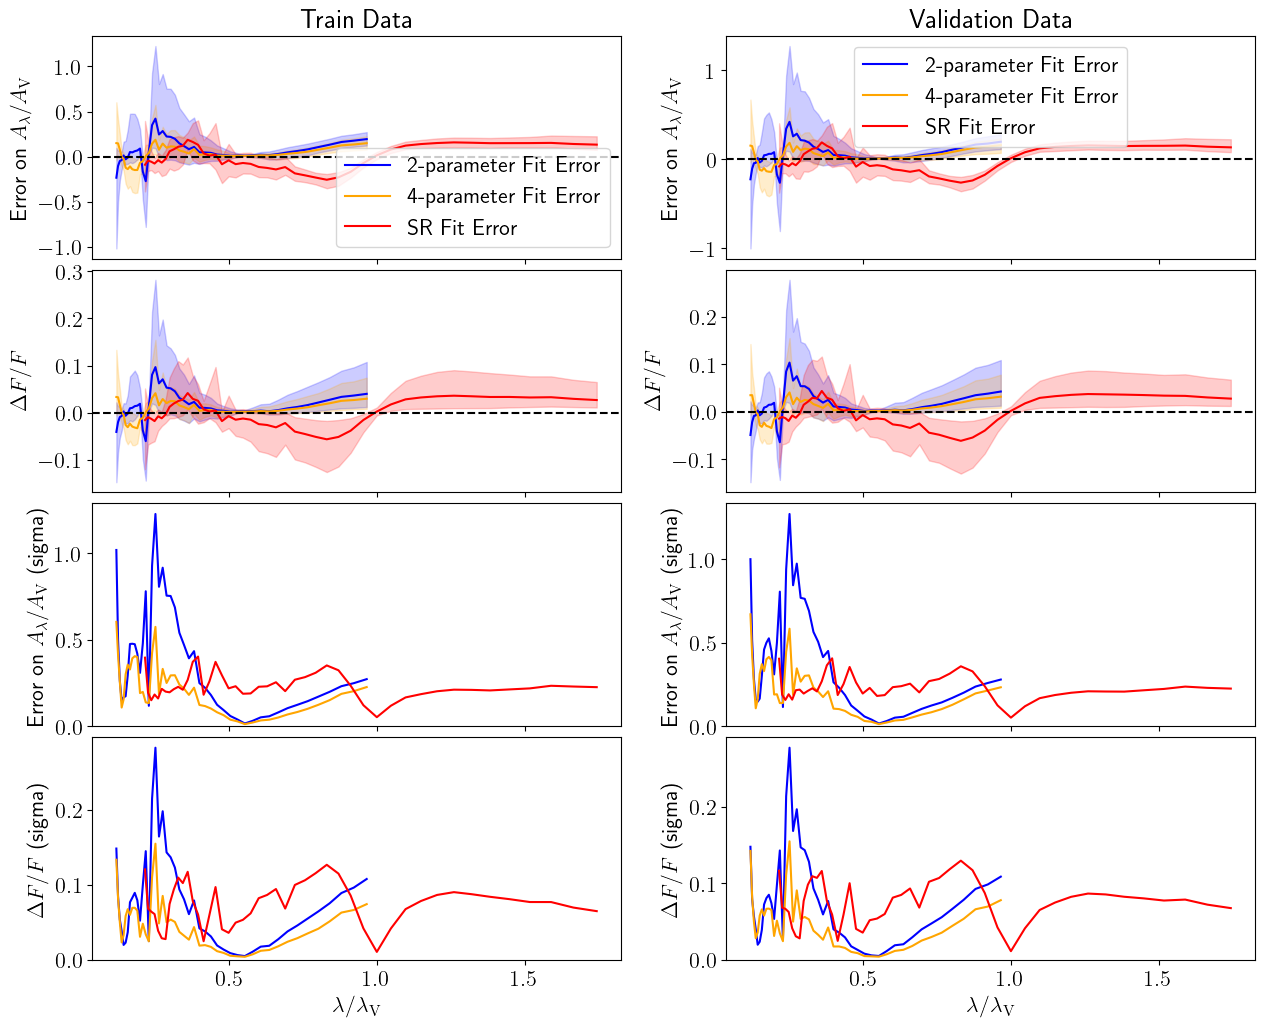

In [93]:
ini_file = 'conf/iob_1.ini'; ilen = 72
ini_file = 'conf/iob_2.ini'; ilen = 51
ini_file = 'conf/iob_3.ini'; ilen = 32
ini_file = 'conf/iob_4.ini'; ilen = 30
ini_file = 'conf/iob_6.ini'; ilen = 32 # quite simple -> rerunning as iob_10 with 24 hours
# ini_file = 'conf/iob_7.ini'; ilen = 27
# ini_file = 'conf/iob_8.ini'; ilen = 32 # not very good
# ini_file = 'conf/iob_9.ini'; ilen = 28
# ini_file = 'conf/iob_10.ini'; ilen = 34
ilen = 32
# ilen = None
# processing_fun.plot_pareto(ini_file, ilen=ilen)
# processing_fun.prediction_plots(ini_file, ilen=ilen);
# processing_fun.plot_example(ini_file, ilen=ilen, nexamples=6);
processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='all', use_optimised=True);

# TO DO: use_optimised=True seems to truncate the literature fits

Test output code


Reading from configuration file: conf/iob_6.ini
1.1562242401210138e-06
0.6440796931067786


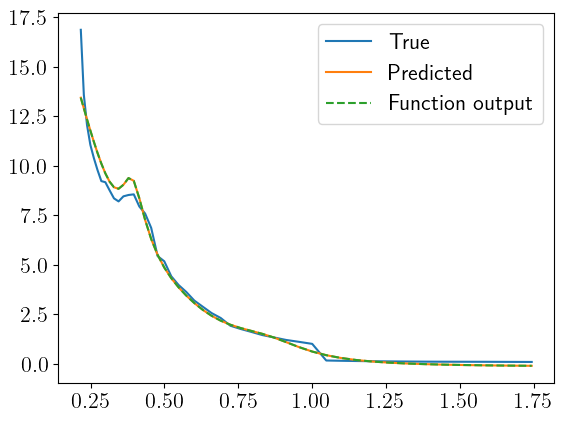

In [70]:
name = 'train'
ini_file = 'conf/iob_6.ini'; ilen = 32

all_data = pd.read_csv('../data/gal_los_iobcomp_attcurve_galprop.dat', sep='\t')
matches = pd.read_csv(f'../symbolic_regression/data/iob_data_10/iob_{name}_galaxy_ids_los.txt', sep='\t',)
matches.rename(columns={"# galaxy_id": "galaxy_id"}, inplace=True)
data_train = all_data.merge(matches, on=['galaxy_id', 'los'], how='inner')
fit_data = pd.read_csv("../data/galaxy_optimization_results.csv")
fit_data.rename(columns={"gal_id": "galaxy_id"}, inplace=True)
data_train = data_train.merge(fit_data, on=['galaxy_id', 'los'], how='inner')

# Get AV
attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
v_index = processing_fun.find_nearest(lam_arr,0.551)

# Get operon data
args = OperonArgs(ini_file)
run_name = f'{args.in_param}_{str(args.version_num)}'
out_dir = pjoin(args.fit_dir, run_name)
fname = f'{out_dir}/{run_name}_fun.csv'
df = pd.read_csv(fname, delimiter=';')
if ilen is None:
    eq_idx = -1
else:
    eq_idx = list(df['Length']).index(ilen)
length = list(df['Length'])[eq_idx]
fname = f'{out_dir}/{run_name}_{name}_{length}.csv'
data = np.loadtxt(fname)
ytrue = data[:,args.npar+1]
ypred = data[:,args.npar+2]
if args.fit_log:
    ypred = 10. ** ypred
    ytrue = 10. ** ytrue
fname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}', f'{args.in_param}_train_data.txt')
with open(fname, 'r') as f:
    header = f.readline().split()
lam = np.unique(np.loadtxt(fname, skiprows=1)[:,header.index('lam')])
ypred = ypred.reshape(-1, len(lam))
ytrue = ytrue.reshape(-1, len(lam))

for i in [4]:
    gal_id = matches['galaxy_id'].values[i]
    los = matches['los'].values[i]
    row = data_train[(data_train['galaxy_id'] == gal_id) & (data_train['los'] == los)]
    iob_cols = sorted([col for col in row.columns if re.match(r'IOB\d+', col)])
    IOB = row[iob_cols].values[0]
    B = sr_fun.compute_initial_B(IOB)
    new_pred = sr_fun.compute_Av(lam, *B)

    plt.plot(lam, ytrue[i], label='True')
    plt.plot(lam, ypred[i], label='Predicted')
    plt.plot(lam, new_pred, label='Function output', ls='--')
    plt.legend()

    print(np.sqrt(np.mean((new_pred - ypred[i])**2)))
    print(np.sqrt(np.mean((ypred[i] - ytrue[i])**2)))

# A_err_op = [None] * getattr(args, f'n{name}')
# df_F_op = [None] * getattr(args, f'n{name}')
# for j in range(getattr(args, f'n{name}')):
#     A_err_op[j] = ypred[j*len(lam):(j+1)*len(lam)] - ytrue[j*len(lam):(j+1)*len(lam)]
#     df_F_op[j] = data[j*len(lam):(j+1)*len(lam),args.npar+3]

# # Get AV
# attenuation_cols = [col for col in all_data.columns if re.match(r'A_\d+A', col)]
# lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
# v_index = processing_fun.find_nearest(lam_arr,0.551)
# Av_name = attenuation_cols[v_index]
# Av = data_train[Av_name].values



# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


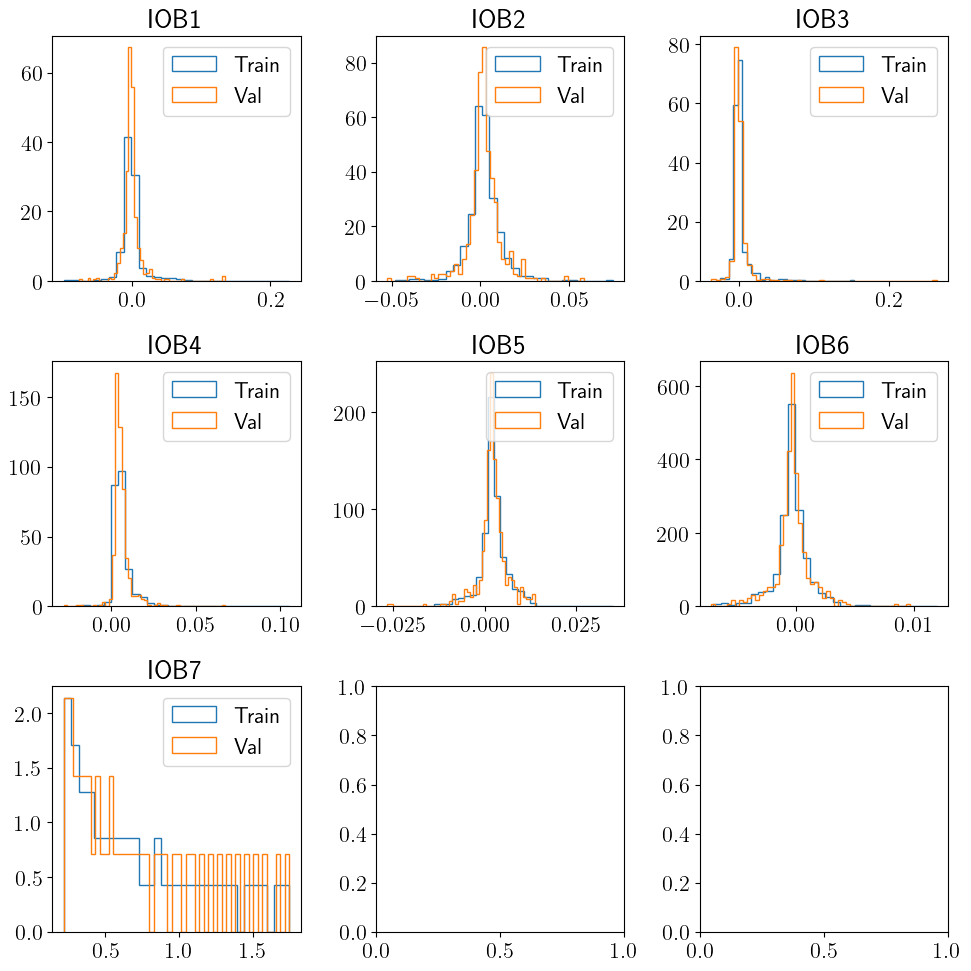

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()